# Simple Linear Regression: Sales vs Advertising
Simple Linear Regression model to study the relationship between Sales and Advertising. The goal is to predict Advertising values using Sales as the independent variable.

## 1. Import Required Libraries

The required Python libraries are imported for data handling, visualization, model building, and model evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 2. Load the Dataset

The dataset is loaded from a text file. Since the file is whitespace-separated and does not contain column headers, custom column names are added after loading.

In [3]:
df=pd.read_csv('sales.txt', delim_whitespace=True, header=None)
df.head()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_86421/3192203264.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df=pd.read_csv('sales.txt', delim_whitespace=True, header=None)


,0,1
0,12.0,15.0
1,20.5,16.0
2,21.0,18.0
3,15.5,27.0
4,15.3,21.0


## 3. Initial Data Understanding

Basic data checks are performed to understand the structure, size, data types, missing values, and statistical summary of the dataset.

In [4]:
df.columns=['Sales','Advertising']

In [5]:
df.head()

,Sales,Advertising
0,12.0,15.0
1,20.5,16.0
2,21.0,18.0
3,15.5,27.0
4,15.3,21.0


In [6]:
df.shape

(36, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        36 non-null     float64
 1   Advertising  36 non-null     float64
dtypes: float64(2)
memory usage: 704.0 bytes


In [8]:
df.describe()

,Sales,Advertising
count,36.000000,36.000000
mean,24.255556,28.527778
std,6.185118,18.777625
min,12.000000,1.000000
25%,20.300000,15.750000
50%,24.250000,23.000000
75%,28.600000,41.000000
max,36.500000,65.000000


In [47]:
print(df.corr())

                Sales  Advertising
Sales        1.000000     0.630767
Advertising  0.630767     1.000000


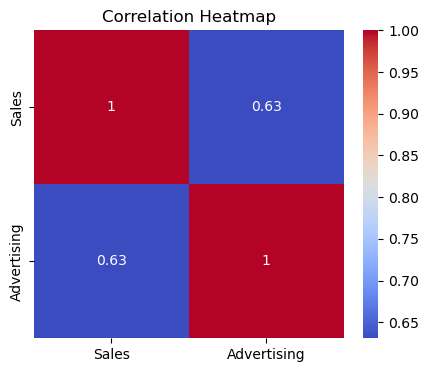

In [48]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')## 4. Define Independent and Dependent Variables

In this model, Sales is used as the independent variable and Advertising is used as the dependent variable.

- Independent variable: Sales  
- Dependent variable: Advertising

plt.title("Correlation Heatmap")
plt.show()

## 4. Define Independent and Dependent Variables

In this model, Sales is used as the independent variable and Advertising is used as the dependent variable.

- Independent variable: Sales  
- Dependent variable: Advertising

In [9]:
X=df[['Sales']]
X.head()

,Sales
0,12.0
1,20.5
2,21.0
3,15.5
4,15.3


In [10]:
y=df[['Advertising']]
y.head()

,Advertising
0,15.0
1,16.0
2,18.0
3,27.0
4,21.0


## 5. Visualize the Relationship

A scatter plot is used to check whether there is a visible linear relationship between Sales and Advertising.

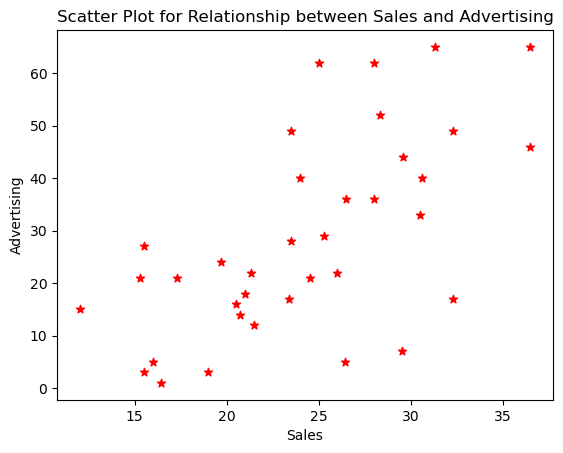

In [11]:
plt.title('Scatter Plot for Relationship between Sales and Advertising')
plt.scatter(X,y,marker='*', color='red')
plt.xlabel('Sales')
plt.ylabel('Advertising')
plt.show()

## 6. Split the Data into Training and Testing Sets

The dataset is split into training and testing data. The training data is used to build the model, and the testing data is used to evaluate model performance on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [13]:
X_train.shape

(28, 1)

In [14]:
X_train.head()

,Sales
8,23.5
17,29.6
9,28.0
34,23.4
0,12.0


In [15]:
X_test.shape

(8, 1)

## 7. Build and Train the Linear Regression Model

A Linear Regression model is created and trained using the training data.

In [16]:
model=LinearRegression()

In [17]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 8. Make Predictions

The trained model is used to predict Advertising values for the test dataset.

In [18]:
y_pred=model.predict(X_test)

## 9. Model Coefficients: Slope and Intercept

The slope and intercept explain the fitted regression line.

The regression equation is:

Advertising = slope × Sales + intercept

In [19]:
#slope
model.coef_

array([[1.66205855]])

In [20]:
#intercept
model.intercept_

array([-12.45519409])

In [49]:
# Regression Equation
slope = model.coef_[0][0]
intercept = model.intercept_[0]

print(f"Regression Equation:")
print(f"Advertising = {slope:.4f} * Sales + {intercept:.4f}")

Regression Equation:
Advertising = 1.6621 * Sales + -12.4552


In [21]:
model.predict(X_test)[:5]

array([[14.80256613],
       [29.59488723],
       [31.58935749],
       [34.58106288],
       [48.20994299]])

In [22]:
y_test[:5]

,Advertising
35,1.0
13,29.0
26,36.0
30,52.0
16,46.0


## 10. Model Evaluation

The model is evaluated using the following regression metrics:

- Mean Squared Error
- Root Mean Squared Error
- R-Square
- Adjusted R-Square

In [23]:
mse=mean_squared_error(y_test, y_pred)
mse

164.3461539052813

In [24]:
rmse=np.sqrt(mse)
rmse

np.float64(12.819756390247099)

In [25]:
r2=r2_score(y_test, y_pred)
r2

0.5875233784338038

In [51]:
print(f"""
Interpretation:
The model explains approximately {r2*100:.2f}% 
of the variance in Advertising using Sales.
""")


Interpretation:
The model explains approximately 58.75% 
of the variance in Advertising using Sales.



In [26]:
X_train.shape

(28, 1)

In [27]:
adj_r2=1-((r2-1)*(X_test.shape[0]-1))/(X_test.shape[1]-X_test.shape[0]-1)
adj_r2

0.6390829561295783

## 13. Residual Error Analysis

Residuals are the differences between actual and predicted values. A residual plot helps check whether the errors are randomly distributed around zero.

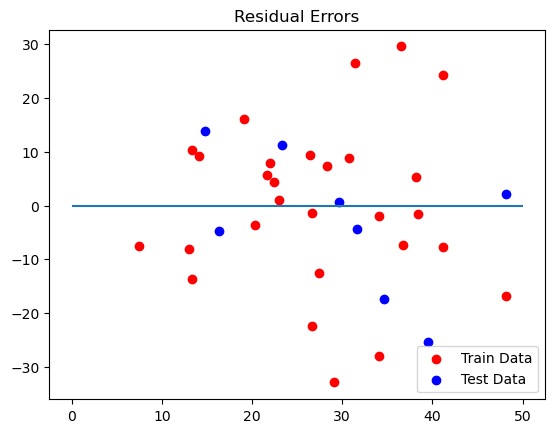

In [46]:
#Plotting Residual 
plt.scatter(model.predict(X_train), model.predict(X_train)-y_train, color='red', label='Train Data')
plt.scatter(model.predict(X_test), model.predict(X_test)-y_test, color='blue', label='Test Data')
plt.hlines(y=0, xmin=0, xmax=50)
plt.title('Residual Errors')
plt.legend(loc = 4)
plt.show()

## 12. Assumptions of Linear Regression

### Assumption 1: Linearity

Linear Regression assumes a linear relationship 
between independent and dependent variables.

The scatter plot below helps visualize whether 
the relationship follows a straight-line trend.

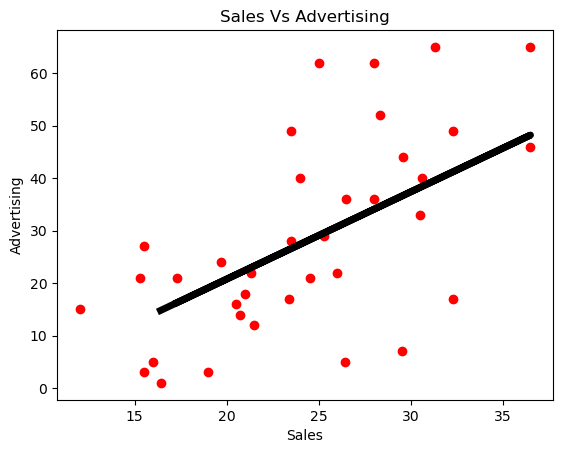

In [28]:
#Plotting Regression Line
plt.scatter(X,y,color='red')
plt.plot(X_test,y_pred,color='black', linewidth=5)
plt.xlabel('Sales')
plt.ylabel('Advertising')
plt.title('Sales Vs Advertising')
plt.show()

# Observation: 
The scatter plot shows a moderately positive linear relationship between Sales and Advertising.

## 2. Independence of Errors
Residuals should not depend on each other.

In [53]:
residuals = y_test.values.flatten() - y_pred.flatten()
residuals

array([-13.80256613,  -0.59488723,   4.41064251,  17.41893712,
        -2.20994299,  25.43276147, -11.27906474,   4.70158117])

In [57]:
from statsmodels.stats.stattools import durbin_watson
# Durbin Watson Test
dw = durbin_watson(residuals)

print("Durbin Watson Statistic:", dw)

Durbin Watson Statistic: 2.37400224776924


## Interpretation:
Durbin-Watson value close to 2 indicates residuals are independent.

0 → strong positive autocorrelation  
4 → strong negative autocorrelation  
2 → no autocorrelation

## Assumption 3: Homoscedasticity

Residuals should have constant variance across predictions.

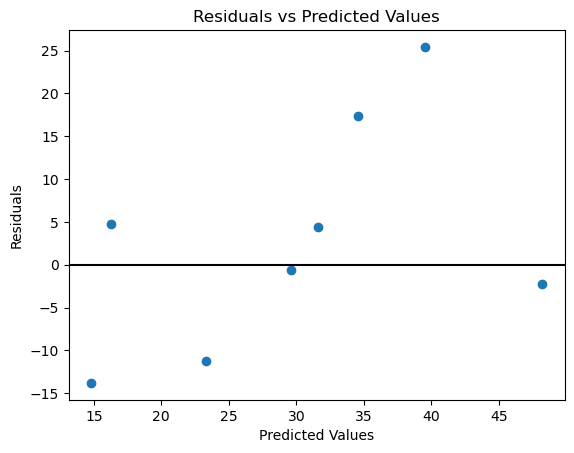

In [60]:
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='black')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

# Observation:
Residuals appear randomly scattered around zero 
with no obvious funnel pattern.

This suggests homoscedasticity is reasonably satisfied.

## 4. Normality of Residuals

Residuals should approximately follow normal distribution.

## Histogram

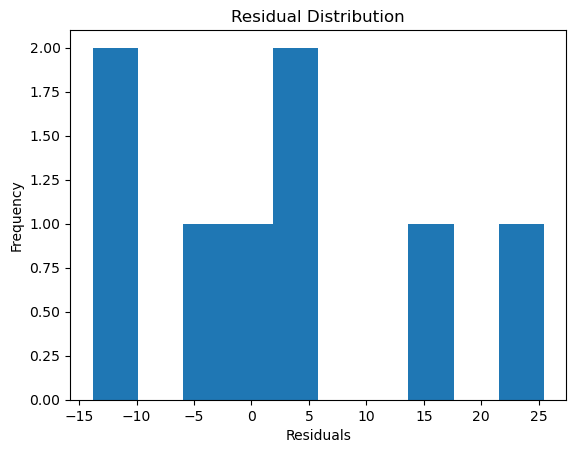

In [61]:
plt.hist(residuals, bins=10)

plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

## QQ-Plot

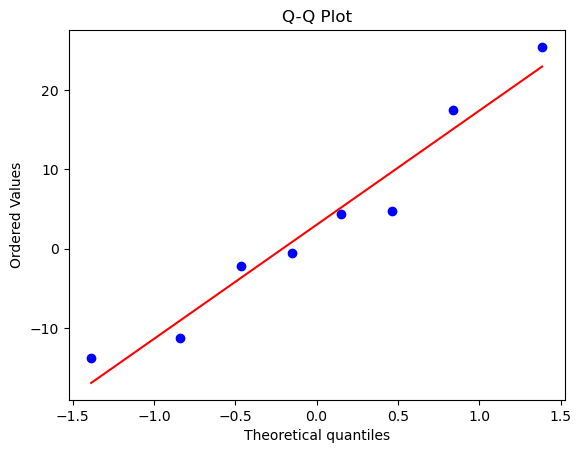

In [62]:
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

## Observation
Residual points approximately follow the straight line,
indicating residuals are reasonably normally distributed.

## Assumption 5: No Multicollinearity

This assumption is not applicable because the model contains 
only one independent variable.

## 6. Outlier Detection

Extreme points should not heavily influence regression line.

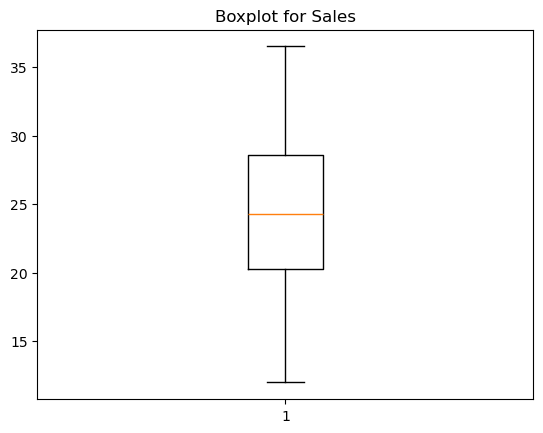

In [63]:
plt.boxplot(df['Sales'])
plt.title("Boxplot for Sales")
plt.show()

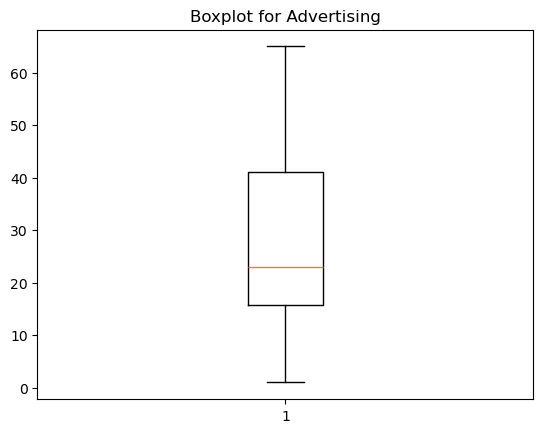

In [64]:
plt.boxplot(df['Advertising'])
plt.title("Boxplot for Advertising")
plt.show()

# Linear Regression Assumption Summary

| Assumption | Status |
|------------|--------|
| Linearity | Satisfied |
| Independence of Errors | Reasonably Satisfied |
| Homoscedasticity | Reasonably Satisfied |
| Normality of Residuals | Approximately Satisfied |
| Multicollinearity | Not Applicable |
| Outliers | No Major Outliers Observed |

## Business Understanding

Businesses often spend money on advertising to improve sales performance.

This project analyzes the relationship between Sales and Advertising using Simple Linear Regression and attempts to predict Advertising values based on Sales data.

Understanding this relationship helps businesses:
- analyze spending patterns
- identify trends
- support decision making
- estimate future advertising requirements